In [1]:
import numpy as np
np.NAN = np.nan
import torch
from deepod.models.time_series import COUTA
from utils.evaluation import evaluate_model
from utils.evaluation_hai import cross_validate_hai
from utils.data_loader_hai import load_hai_train
from utils.hyperparameter_search_hai import run_optuna_study_hai
result_path = "../Results/HAI COUTA"

C:\Users\louis\PycharmProjects\Exjobb-Gitrepo\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
hyperparameters = {
    "lr": ("categorical", [1e-5, 1e-4, 1e-3]),
    "rep_dim": ("int", 8, 32, False),
    "epochs": ("int", 20, 80, False),
}

study = run_optuna_study_hai(
    model_class=COUTA,
    hyperparameters=hyperparameters,
    n_trials=10,
    study_name="couta_hai_optuna_actual_study",
    storage="sqlite:///couta_hai_optuna_actual.db"
)

print("Best params:", study.best_params)
print("Best validation score:", study.best_value)
print("Best trial extra metrics:", study.best_trial.user_attrs)

Best params: {'lr': 0.0001, 'rep_dim': 13, 'epochs': 31}
Best validation score: 0.2842155883055633
Best trial extra metrics: {'pr_auc': 0.2842155883055633}


In [3]:
best_params = study.best_params
static_params = {
    "seq_len": 50,
    "stride": 5,
    "train_val_pc": 0
}

params = best_params | static_params
cross_val_scores = cross_validate_hai(model=COUTA, params=params, result_path=result_path)
print(cross_val_scores)

{'fold1_roc_auc': 0.6583175932431095, 'fold1_pr_auc': 0.3482635523160455, 'fold2_roc_auc': 0.37041839225351486, 'fold2_pr_auc': 0.027317033616588264, 'fold3_roc_auc': 0.49393593740857367, 'fold3_pr_auc': 0.1992921578279269, 'fold4_roc_auc': 0.5881476570502879, 'fold4_pr_auc': 0.1886345751181134, 'mean_threshold': np.float64(0.09258508761413395)}


In [4]:
X_train, X_test, y_test = load_hai_train()

model = COUTA(**params)

model.fit(X_train)

scores = model.decision_function(X_test)

|>>> epoch: 31  |   loss: 0.001841, loss_oc: 0.000000, val_loss: nan


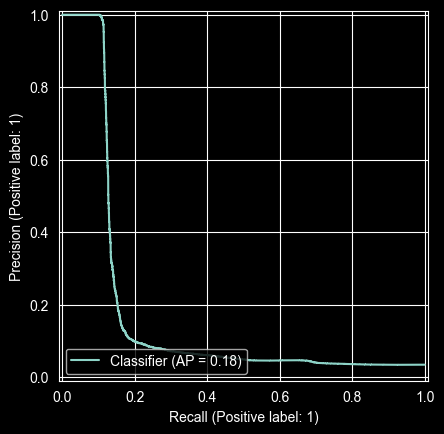

In [5]:
results = evaluate_model(y_test, scores, threshold=cross_val_scores["mean_threshold"], result_path=result_path)
print(results)

In [6]:
import pandas as pd
import os
df = pd.DataFrame(scores, columns=["score"])
scores_path = os.path.join(result_path, "scores.csv")
df.to_csv(scores_path, index=False)